# Aufgaben Interpretation und Representation Learning

### Aufgabe 1: Embeddings

*Nutzen Sie t-SNE und PCA um einen beliebigen Klassifikations-Datensatz auf zwei Dimensionen zu reduzieren. Zeigen Sie die Teilung nach Klassen grafisch auf!*


In [ ]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    StandardScaler,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import torch.nn as nn  # Modul für Neuronale Netzwerke (Layer, Aktivierungsfunktionen etc.)
import torch.optim as optim  # Modul für Optimierungsalgorithmen
import torchvision  # Enthält Datensätze (wie MNIST) und Transformationen
import torchvision.transforms as transforms

In [ ]:
# Laden des gewählten Datensatzes

# Skalierung der Features (Standardisierung), wichtig für PCA und tSNE
# Ohne Skalierung würden Merkmale mit größeren Wertebereichen die Distanzberechnung dominieren
scaler = StandardScaler()


Originale Features (X) Form:  (569, 30)
Target (y) Form:  (569,)
Zielklassen:  ['malignant' 'benign']

Skalierte Features (X_scaled) Form:  (569, 30)


In [ ]:
# PCA: Reduzieren auf 2 Dimensionen

# tSNE:  Reduzieren auf 2 Dimensionen
# tSNE benötigt weitere Hyperparameter, nachschauen welche die TSNE Funktion erwartet



PCA reduzierte Datenform:  (569, 2)
Erklärte Varianz durch die ersten 2 PCs: 0.6324


/Users/lauraboenchen/Workspace/Digethic/full-stack-machine-learning/.venv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE reduzierte Datenform:  (569, 2)


In [ ]:
# Plotten der PCA-Ergebnisse und t-SNE-Ergebnisse
fig, axes = plt.subplots(2, 1, figsize=(10, 10))



NameError: name 'plt' is not defined

### Aufgabe 2: Autoencoder

*Implementieren Sie einen Autoencoder in PyTorch! Encoden und Decoden Sie einen beliebigen Datensatz (bspw. MNIST).*


In [ ]:
# Sicherstellen, dass PyTorch die GPU verwenden kann, falls verfügbar


Verwende Gerät: cpu


In [ ]:
# Definieren von Transformationen für die Bilder:
# 1. ToTensor: Wandelt PIL-Bilder oder NumPy-Arrays in PyTorch-Tensoren um (und skaliert Pixelwerte von [0, 255] auf [0, 1])
# 2. Normalize: Normalisiert die Tensoren mit einem gegebenen Mittelwert und Standardabweichung
#    Für MNIST ist der Mittelwert 0.1307 und die Standardabweichung 0.3081. Dies hilft dem Training
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.1307,), (0.3081,)
        ),  # Mittelwert und Std.abw. für MNIST (ein Kanal)
    ]
)

# Laden des Trainings- und Testdatensatzes
# download=True lädt den Datensatz herunter, falls er noch nicht vorhanden ist
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

# Definieren von DataLoadern
# DataLoader helfen beim Batching und Shuffling der Daten
batch_size = 64  # Anzahl der Samples pro Batch
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

print(f"Anzahl der Trainingsbilder: {len(train_dataset)}")
print(f"Anzahl der Testbilder: {len(test_dataset)}")
print(f"Größe eines Bildes (vor Flattening): {train_dataset[0][0].shape}")


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 240kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.89MB/s]

Anzahl der Trainingsbilder: 60000
Anzahl der Testbilder: 10000
Größe eines Bildes (vor Flattening): torch.Size([1, 28, 28])


In [ ]:
# Parameter für den Autoencoder
# input_size = Anzahl der Pixel der Bilder
# hidden_size_1 = Größe der ersten versteckten Schicht
# latent_dim =  Dimension des latenten Raums
# hidden_size_2 = Größe der zweiten versteckten Schicht (im Decoder)
# output_size = input_size  # Die Ausgabe sollte dieselbe Größe wie die Eingabe haben (Rekonstruktion)


class Autoencoder(nn.Module):
    def __init__(
        self, input_size, hidden_size_1, latent_dim, hidden_size_2, output_size
    ):
        # initialisieren des geerbten Moduls
        super(Autoencoder, self).__init__()

        # Der Encoder reduziert die Dimensionalität der Eingabedaten.
        # Erster Layer: Eingabe  -> hidden_size_1

        # Zweiter Layer (zum latenten Raum): hidden_size_1 -> latent_dim

        # Der Decoder rekonstruiert die ursprünglichen Daten aus dem latenten Raum.
        # Erster Layer: latent_dim -> hidden_size_2

        # Zweiter Layer (Ausgabe): hidden_size_2 -> output_size

        # Sigmoid Aktivierungsfunktion
        # Eine Sigmoid-Aktivierung am Ende des Decoders

    def forward(self, x):

        # Encoder
        # ReLU-Aktivierung der ersten Encoder-Layer anwenden

        # Relu Aktivierung durch die zweite Layer


        # Decoder
        # ReLU-Aktivierung auf die erste Decoder Layer anwenden


        # Sigmoid-Aktivierung anwenden, um die Ausgabe in den Bereich [0,1] zu bringen (für Visualisierung wichtig)
        #    Hinweis: Wenn die Eingabedaten normalisiert sind (z.B. auf Mittelwert 0, Std.abw. 1),
        #    muss man überlegen, ob die Ausgabe auch normalisiert sein soll oder zurück in [0,1] für die Visualisierung
        #    Für MNIST-Pixel ist [0,1] üblich

        # return (
        #     reconstruction,
        #     latent,
        # )  # Gib sowohl die Rekonstruktion als auch den latenten Vektor zurück


# Modell initialisieren und auf das ausgewählte Gerät (CPU/GPU) verschieben
model = Autoencoder(
    input_size, hidden_size_1, latent_dim, hidden_size_2, output_size
).to(device)

print("Autoencoder Modellarchitektur:")
print(model)


Autoencoder Modellarchitektur:
Autoencoder(
  (encoder_fc1): Linear(in_features=784, out_features=256, bias=True)
  (encoder_relu1): ReLU()
  (encoder_fc2): Linear(in_features=256, out_features=64, bias=True)
  (encoder_relu2): ReLU()
  (decoder_fc1): Linear(in_features=64, out_features=256, bias=True)
  (decoder_relu1): ReLU()
  (decoder_fc2): Linear(in_features=256, out_features=784, bias=True)
  (decoder_sigmoid): Sigmoid()
)


In [ ]:
# Verlustfunktion: Mean Squared Error (MSE) ist passend für Rekonstruktionsaufgaben
criterion = nn.MSELoss()

# Optimierer: Adam wird oft verwendet und ist eine gute allgemeine Wahl
learning_rate = 0.001  # Lernrate: Bestimmt die Schrittgröße der Gewichtsaktualisierung
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Verlustfunktion:  MSELoss()
Optimierer: 
 Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# Anzahl der Epochen
num_epochs = 20

# Zum Speichern des Verlustverlaufs zur späteren Darstellung
train_losses = []

print("Starte Training des Autoencoders...")
for epoch in range(num_epochs):
    epoch_loss = 0.0  # Verlust für die aktuelle Epoche

    # Iteriere über alle Batches im Trainings-DataLoader
    for batch_idx, (data, _) in enumerate(
        train_loader
    ):  # MNIST hat auch Labels, die wir hier nicht nutzen (Autoencoder ist unsupervised)
        data = data.view(-1, input_size).to(
            device
        )

        # Gradienten in jeder iteration zurücksetzen

        # Forward-Pass: Rekonstruktion und latenten Vektor erhalten
        reconstruction, latent_representation = model(data)

        # Verlust berechnen: MSE zwischen Originaldaten und Rekonstruktion

        # Backward-Pass: Gradienten berechnen

        # Gewichte aktualisieren

        # Verlust des aktuellen Batches addieren

    # Durchschnittlicher Verlust pro Epoche
    # train_losses.append(avg_epoch_loss)

    # Gebe den Verlust periodisch aus
    print(
        f"Epoche [{epoch + 1}/{num_epochs}], Durchschnittlicher Verlust: {avg_epoch_loss:.4f}"
    )

print("Training beendet.")


Starte Training des Autoencoders...
Epoche [1/20], Durchschnittlicher Verlust: 0.6041
Epoche [2/20], Durchschnittlicher Verlust: 0.5273
Epoche [3/20], Durchschnittlicher Verlust: 0.5151
Epoche [4/20], Durchschnittlicher Verlust: 0.5100
Epoche [5/20], Durchschnittlicher Verlust: 0.5063
Epoche [6/20], Durchschnittlicher Verlust: 0.5039
Epoche [7/20], Durchschnittlicher Verlust: 0.5023
Epoche [8/20], Durchschnittlicher Verlust: 0.5011
Epoche [9/20], Durchschnittlicher Verlust: 0.5001
Epoche [10/20], Durchschnittlicher Verlust: 0.4994
Epoche [11/20], Durchschnittlicher Verlust: 0.4989
Epoche [12/20], Durchschnittlicher Verlust: 0.4983
Epoche [13/20], Durchschnittlicher Verlust: 0.4976
Epoche [14/20], Durchschnittlicher Verlust: 0.4968
Epoche [15/20], Durchschnittlicher Verlust: 0.4965
Epoche [16/20], Durchschnittlicher Verlust: 0.4962
Epoche [17/20], Durchschnittlicher Verlust: 0.4958
Epoche [18/20], Durchschnittlicher Verlust: 0.4954
Epoche [19/20], Durchschnittlicher Verlust: 0.4953
Epoc

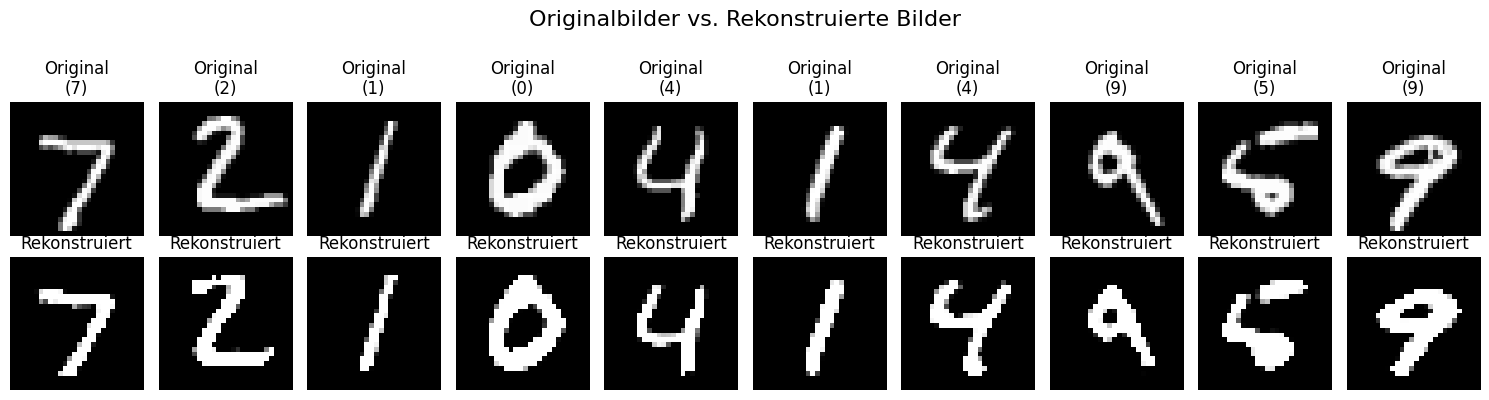

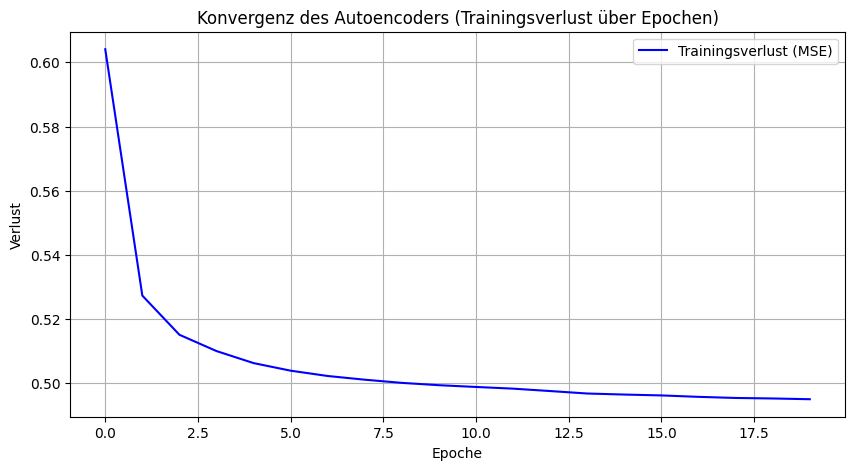

In [ ]:
# Setze das Modell in den Evaluierungsmodus (wichtig, falls Batch-Norm/Dropout verwendet wird)
model.eval()

# Deaktiviere die Gradientenberechnung für die Inferenz
with torch.no_grad():
    # Hole einen Batch von Bildern aus dem Test-DataLoader
    data_iter = iter(test_loader)
    images, labels = next(data_iter)

    # Nimm die ersten 10 Bilder des Batches zur Visualisierung
    num_display = 10
    original_images = images[:num_display].to(device)

    # Flatten der Bilder für den Autoencoder
    original_images_flat = original_images.view(-1, input_size)

    # Rekonstruktion durch den Autoencoder
    reconstructed_images_flat, _ = model(original_images_flat)

    # Rekonstruierte Bilder wieder in 2D-Format bringen (28x28)
    reconstructed_images = reconstructed_images_flat.view(
        -1, 1, 28, 28
    ).cpu()  # Zurück auf CPU für Matplotlib
    original_images = original_images.cpu()

    # Visualisierung der originalen und rekonstruierten Bilder
    fig, axes = plt.subplots(2, num_display, figsize=(15, 4))  # 2 Zeilen, 10 Spalten

    for i in range(num_display):
        # Originalbilder in der oberen Reihe
        axes[0, i].imshow(original_images[i].squeeze(), cmap="gray")
        axes[0, i].set_title(f"Original\n({labels[i].item()})")
        axes[0, i].axis("off")  # Achsen ausblenden

        # Rekonstruierte Bilder in der unteren Reihe




# Plot des Trainingsverlusts, um die Konvergenz zu zeigen
